**P1_8**

Nombres de los integrantes del grupo:

- APONTE ZURITA WILLIAM ROMARIO
- VITERI AYALA FLAVIA KAMILA

## <center>**Ejercicio práctico semana 1**</center>

<b>Maestría</b>: Inteligencia Artificial Aplicada <br>
<b>Asignatura:</b> Procesamiento Acelerado de Lenguaje Natural <br>
<b>Profesor:</b> Edwin J. Rueda

**Bienvenidos** al ejercicio práctico de la primera semana. A parte de las preguntas prácticas y teóricas que deberás responder, ten en cuenta lo siguiente:
- Encontrarás enlaces a documentación externa que te ayudará a resolver dudas.
- Resuelve los ejercicios de forma secuencial. Para que puedas ver el avance.
- La idea es guiarte sobre el proceso, por lo cual, encontrarás funciones pre-definidas.
    Por lo cual deberás colocar el código faltante dentro de las etiquetas especificadas.
- Encontrarás una salida esperada en cada celda para que tengas una guía. (Ten en cuenta que una vez ejecutada la celda, esta salida desaparecera).

### Dataset

Para este ejercicio práctico utilizaremos una fracción del dataset de MeLi. El dataset cuenta con 60k registros, los cuales hacen referencia al titulo de un producto y a su respectiva categoria. El objetivo del entregable es realizar un procesamiento del conjunto de datos con los métodos vistos en clase. Finalmente, veremos como se reduce la dimensionalidad y que tokens se vuelven más relevantes.

El dataset cuenta con la siguiente información:

    - title: Descripción del titúlo del producto
    - category: Categoria a la cual pertenece el producto

#### Descargar y visualizar el conjunto de datos

El conjunto de datos se encuentra público y puedes descargarlo [aquí](https://drive.google.com/file/d/1ivgFoL4HXwmc0u9n-rPR5c5U5lt5_Eds/view?usp=sharing). En este ejemplo, estará sobre la misma ruta donde se encuentra el notebook, por lo cual lo leemos con la función *read_csv* de [Pandas](https://pandas.pydata.org/docs/).

In [3]:
import pandas as pd
from time import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
url = "https://raw.githubusercontent.com/fkviteri/uide-maestria/main/04-procesamiento-acelerado-lenguaje-natural/filter_data.csv"

data = pd.read_csv(url, index_col=0)

data.head()

,title,category
0,Campera Ls2 Hombre Discovery Black Solo En Mg ...,MOTORCYCLE_JACKETS
1,Peine Beiyuan 13 Dientes,COMBS
2,Collar Arranque Fiat Palio Siena Strada Pin Fi...,IGNITION_SWITCH_ACTUATORS
3,Lampara Compatible Benq Ms517f Por Pedido,PROJECTOR_LAMPS
4,Canilla Doble Esférico Riego Prog Lavarropa Fv...,IRRIGATION_VALVES


Primeramente, podemos obtener estadisticas de los datos:

In [5]:
print(f"Dimensionalidad de los datos: {data.shape}")
print(f"Cantidad de categorias de productos: {len(data.category.unique())}")

Dimensionalidad de los datos: (60000, 2)
Cantidad de categorias de productos: 1543


In [6]:
data.describe()

,title,category
count,60000,60000
unique,59824,1543
top,Botines Nike Phantom 3 Academy Df Fg Cesped Ah...,FOOTBALL_SHIRTS
freq,2,137


Algo muy útil es entender la distribución de los datos, en este caso en particular, de las categorías. Esto no permitirá entender los resultados obtenidos en nuestro modelo de aprendizaje supervisado. Para ello, podemos hacer uso del método *groupby* y *count*:

In [7]:
categories = data.groupby("category").count()
categories.head()

,title
category,
3D_GLASSES,10
3D_PRINTERS,20
3D_PRINTER_FILAMENTS,28
ABDOMINAL_TONING_BELTS,5
ABS_SENSORS,42


Otra buena práctica es observar la distribución de los datos. En este caso resulta útil ver la distribución de las categorías. Lo que nos permite enteder un poco mas a detalle los resultados que tengan nuestros modelos de AI.

In [8]:
categories.sort_values(by="title")

,title
category,
QUEUE_STANCHIONS,1
CHESS_CLOCKS,1
CNC_MACHINING_CENTERS,1
SOLDERING_STATIONS,1
POLY_MAILERS,1
...,...
DOLLS,121
SPARK_PLUGS,124
MINI_COMPONENT_SYSTEMS,126


Podemos obtener la cantidad de palabras únicas en nuestro conjunto de datos antes de ser preprocesado:

In [7]:
data_init_word_count = len(np.unique(' '.join(data['title']).split()))
print(f"Tamaño inicial de palabras únicas del dataset: {data_init_word_count} palabras")

Tamaño inicial de palabras únicas del dataset: 75794 palabras


## <center>**Procesamiento**</center>

### **Pregunta 1:**

##### **¿Crees que para los pasos de pre-procesamiento de los datos influya el tener categorías con un solo producto y otras con mas de 100 productos?**

Aunque el preprocesamiento se aplique de igual forma a todos los títulos, su impacto varía según la cantidad de ejemplos por categoría. En categorías con suficientes productos, la normalización (como eliminación de stopwords o lematización) fortalece la señal al consolidar términos equivalentes, reducir dimensionalidad y facilitar que el modelo aprenda patrones más robustos y generalizables.

En cambio, en categorías con muy pocos ejemplos, especialmente aquellas con un único producto, ese mismo proceso puede ser perjudicial. Si la única palabra distintiva del título se modifica agresivamente o se elimina, se pierde toda la señal discriminativa disponible, dejando al modelo sin información suficiente para reconocer esa clase.

Además, este efecto suele quedar oculto en métricas globales como accuracy o F1 promedio, ya que el buen desempeño en clases mayoritarias compensa artificialmente el fracaso en clases minoritarias. Por ello, en corpus desbalanceados conviene usar preprocesamiento más conservador, tokenización por subpalabras o estrategias para reforzar categorías con pocos ejemplos.

### **Pre-procesamiento del corpus**

Para el preprocesamiento del corpus, desarrollaremos dos *pipelines*:
- Stemmer_pipeline: Este, como su nombre lo indica, se basará en sacar la raíz de las palabras. No obstante, hará los siguentes pasos:
  1. Llevará todas las palabras a minúsculas
  2. Eliminará las *stopwords*
  3. hará stemming de todo el corpus.

- Lemma_pipeline: Este, a diferencia del *Stemmer_pipeline*, realizará lematización de las palabras:
  1. Llevará todas las palabras a minúsculas
  2. Eliminará las *stopwords*
  3. Obtendrá el *lemma* de cada palabra.

#### **Ejercicio 1:**

Se debe construir una función que dado un string, retorne dicho string en minúsculas:

In [9]:
def get_lower_case(sentence):

    ### TU CÓDIGO AQUÍ ###

    result = sentence.lower()

    ######################

    return result

example = data.iloc[19]["title"]
lower_example = get_lower_case(example)
print(f"Sentencia original → {example}")
print(f"Sentencia procesada → {lower_example}")

Sentencia original → Zapatilla Importada Azul Niño Talle 29 En Temperley!!!
Sentencia procesada → zapatilla importada azul niño talle 29 en temperley!!!


#### **Ejercicio 2:**

Ahora podemos calcular la reducción de la dimensionalidad después de llevar el corpus a minúsculas. ¿Cuantas palabras se redujimos?

In [10]:
### TU CODIGO AQUÍ ###

# Antes del preprocesamiento
data_init_word_count = len(np.unique(' '.join(data['title']).split()))

# Aplicar lower case
data_lower = data['title'].apply(get_lower_case)

# Después del preprocesamiento
data_lower_word_count = len(np.unique(' '.join(data_lower).split()))

print(f"Palabras únicas antes: {data_init_word_count}")
print(f"Palabras únicas después: {data_lower_word_count}")
print(f"Reducción de dimensionalidad: {data_init_word_count - data_lower_word_count}")

######################

Palabras únicas antes: 75794
Palabras únicas después: 75627
Reducción de dimensionalidad: 167


#### **Ejercicio 3:**
Ahora vamos a construir la función para eliminar las stopwords. Para ello, es necesario que cumpla lo siguiente:
- Recibir como entrada un string en minúsculas
- Iterar sobre cada palabra dentro del string para poder descartar las *stopwords*
- Retornar la nueva oración sin *stopwords*

In [11]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

spanish_stop_words = set(stopwords.words("spanish"))

def delete_stop_words(sentence):
    ### TÚ CÓDIGO AQUÍ ###
    # Optimizamos moviendo la creación del set fuera de la función
    result = " ".join([word for word in sentence.split() if word not in spanish_stop_words])
    ######################
    return result


print(f"Sentencia original -> {lower_example}")
example_sw = delete_stop_words(lower_example)
print(f"Sentencia sin stopwords -> {example_sw}")

Sentencia original -> zapatilla importada azul niño talle 29 en temperley!!!
Sentencia sin stopwords -> zapatilla importada azul niño talle 29 temperley!!!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#### **Ejercicio 4:**

Ahora podemos calcular la reducción de la dimensionalidad después de eliminar del **corpus con lowercasing** las stop words. ¿Cuantas palabras se redujimos?

In [12]:
### TU CODIGO AQUÍ ###

data_sw = data_lower.apply(delete_stop_words)
data_sw_word_count = len(np.unique(' '.join(data_sw).split()))

print(f"Tamaño de palabras únicas después de eliminar stop words: {data_sw_word_count} palabras")
print(f"Reducción de la dimensionalidad: {data_lower_word_count - data_sw_word_count} Palabras")

######################

Tamaño de palabras únicas después de eliminar stop words: 75519 palabras
Reducción de la dimensionalidad: 108 Palabras


### **Pregunta 2:**

##### **¿Crees que las mayúsculas o las *stopwords* pueden aportar a esta tarea y que eliminarlas sea un error?**

Tanto las mayúsculas como las stopwords pueden contener información útil, por lo que eliminarlas no siempre es una decisión neutra. Las mayúsculas pueden ayudar a identificar marcas, acrónimos o modelos de productos; sin embargo, en este corpus específico, donde los títulos siguen uniformemente un formato Title Case, esa capitalización responde más a un estilo editorial que a una señal semántica, por lo que convertir todo a minúsculas no implica una pérdida relevante de información.

En el caso de las stopwords, su eliminación requiere mayor cautela, especialmente en títulos cortos, donde cada palabra aporta proporcionalmente más significado. Términos como “sin”, “para” o “contra” pueden cambiar completamente el sentido de un producto al indicar negación, función o destinatario. Eliminarlas sin criterio podría reducir significativamente la capacidad del modelo para interpretar correctamente ciertos títulos.

Por ello, la conveniencia de eliminarlas depende de la tarea analítica. En modelos clásicos de clasificación pueden ayudar a reducir ruido, pero en tareas donde el contexto semántico es clave (como análisis de sentimiento, búsqueda semántica o modelos preentrenados) su conservación suele ser preferible. Una estrategia equilibrada es utilizar una lista de stopwords personalizada que preserve términos informativos del dominio.

#### **Ejercicio 5:**

Crear una función que nos permita lematizar las palabras/tokens dentro de unas sentencia y nos retorne la nueva sentencia lematizada:

In [14]:
import sys
!python -m spacy download es_core_news_sm

import spacy
nlp_pipe = spacy.load("es_core_news_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 84.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [15]:
def get_lemmas(sentence):
    ### TÚ CÓDIGO AQUÍ ###

    doc = nlp_pipe(sentence)
    result = " ".join([token.lemma_ for token in doc])

    ######################
    return result

print(f"Sentencia original -> {example_sw}")
example_lemma = get_lemmas(example_sw)
print(f"Sentencia lemmatizada -> {example_lemma}")

Sentencia original -> zapatilla importada azul niño talle 29 temperley!!!
Sentencia lemmatizada -> zapatilla importado azul niño talle 29 temperley ! ! !


#### **Ejercicio 6:**
Crear una función para sacar la raíz de cada palabra dentro de una oración y retornar la sentencia nueva procesada:

In [16]:
from nltk.stem.snowball import SnowballStemmer

def get_stemmer(sentence):
    ### TU CÓDIGO AQUÍ ###

    stemmer = SnowballStemmer('spanish')
    result = " ".join([stemmer.stem(word) for word in sentence.split()])

    ######################
    return result

print(f"Sentencia original -> {example_sw}")
example_stemmer = get_stemmer(example_sw)
print(f"Sentencia stemming -> {example_stemmer}")

Sentencia original -> zapatilla importada azul niño talle 29 temperley!!!
Sentencia stemming -> zapatill import azul niñ tall 29 temperley!!!


#### **Ejercicio 7:**

Ahora podemos calcular la reducción de la dimensionalidad después de hacer stemming sobre el corpus con **lowercasing y sin stop words** ¿Cuantas palabras se redujimos?

In [17]:
### TU CODIGO AQUÍ ###
data_stemmer_temp = data_sw.apply(get_stemmer)
data_stemmer_word_count = len(np.unique(' '.join(data_stemmer_temp).split()))

print(f"Tamaño de palabras únicas después de hacer stemming: {data_stemmer_word_count} palabras")
print(f"Reducción de la dimensionalidad: {data_sw_word_count - data_stemmer_word_count} Palabras")
######################

Tamaño de palabras únicas después de hacer stemming: 66102 palabras
Reducción de la dimensionalidad: 9417 Palabras


#### **Ejercicio 8:**

Con las funciones de procesamiento definidas, construiremos nuestra función *pipeline*, la cual procesará los datos dependiendo de un parámetro de entrada que define si queremos sacar el *lemma* o el *stemmer* de los tokens.

Nuestra función *pipeline* debe cumplir con los siguientes requisitos:
- recibir como entrada los siguientes parámetros:
    - df: dataframe con las columnas *title* y *category*
    - method: string identificando si es *stemmer* o *lemma* el procesado
- debe retornar el nuevo dataframe procesado, manteniendo el nombre de las columnas

In [18]:
def pipeline(df, method="stemmer"):
    """
    df: dataframe
    method: stemmer o lemma
    """
    df = df.copy()
    # Pre-procesamiento inicial (Lower case y Stopwords)
    print(f"Iniciando pre-procesamiento ({method})...")
    texts = [delete_stop_words(get_lower_case(t)) for t in df["title"]]

    if method == "stemmer":
        stemmer = SnowballStemmer('spanish')
        df["title"] = [" ".join([stemmer.stem(w) for w in t.split()]) for t in texts]
    elif method == "lemma":
        # USAMOS nlp.pipe PARA PROCESAMIENTO EN LOTES (MUCHO MÁS RÁPIDO)
        lemmas = []
        for doc in nlp_pipe.pipe(texts, batch_size=500):
            lemmas.append(" ".join([token.lemma_ for token in doc]))
        df["title"] = lemmas

    return df

Procesamos el dataset con el método *stemmer*:

In [19]:
tic = time()
data_stemmer = pipeline(data, method="stemmer")
toc = time()
print(f"Tiempo de procesamiento: {(toc-tic)/60} [min]")
data_stemmer.head()

Iniciando pre-procesamiento (stemmer)...
Tiempo de procesamiento: 0.19329280455907186 [min]


,title,category
0,camper ls2 hombr discovery black sol mg bik,MOTORCYCLE_JACKETS
1,pein beiyu 13 dient,COMBS
2,coll arranqu fiat pali sien strad pin fin 140mm,IGNITION_SWITCH_ACTUATORS
3,lamp compat benq ms517f ped,PROJECTOR_LAMPS
4,canill dobl esfer rieg prog lavarrop fv 436.04...,IRRIGATION_VALVES


Procesamos el dataset con el método *lemma*:

In [20]:
tic = time()
data_lemma = pipeline(data, method="lemma")
toc = time()
print(f"Tiempo de procesamiento: {(toc-tic)/60} [min]")
data_lemma.head()

Iniciando pre-procesamiento (lemma)...
Tiempo de procesamiento: 1.374867598215739 [min]


,title,category
0,camperar ls2 hombre discovery black solo mg bikes,MOTORCYCLE_JACKETS
1,peine beiyuan 13 diente,COMBS
2,collar arrancar fiat palio siena strado pin fi...,IGNITION_SWITCH_ACTUATORS
3,lampar compatible benq ms517f pedido,PROJECTOR_LAMPS
4,canilla doble esférico riego prog lavarropa fv...,IRRIGATION_VALVES


## <center>**Análisis del Procesamiento**</center>

Una de las formas sencillas de obtener una vista inicial de la frecuencia de los *tokens* en el corpus es mediante un [word cloud](https://github.com/amueller/word_cloud/blob/main/README.md). Con este, podemos visualmente observar que tanto cambio la frecuencia al aplicar el *stemming* o la *lemmatization*

In [21]:
!pip install wordcloud

Para poder crear el *word cloud* necesitamos generar un único corpus:

In [22]:
corpus_init = " ".join(row["title"] for indx, row in data.iterrows())
corpus_lemma = " ".join(row["title"] for indx, row in data_lemma.iterrows())
corpus_stemmer = " ".join(row["title"] for indx, row in data_stemmer.iterrows())

In [23]:
# import sys
# !{sys.executable} -m pip install wordcloud

from wordcloud import WordCloud

wc_init = WordCloud(background_color="white").generate(corpus_init)
wc_lemma = WordCloud(background_color="white").generate(corpus_lemma)
wc_stemmer = WordCloud(background_color="white").generate(corpus_stemmer)

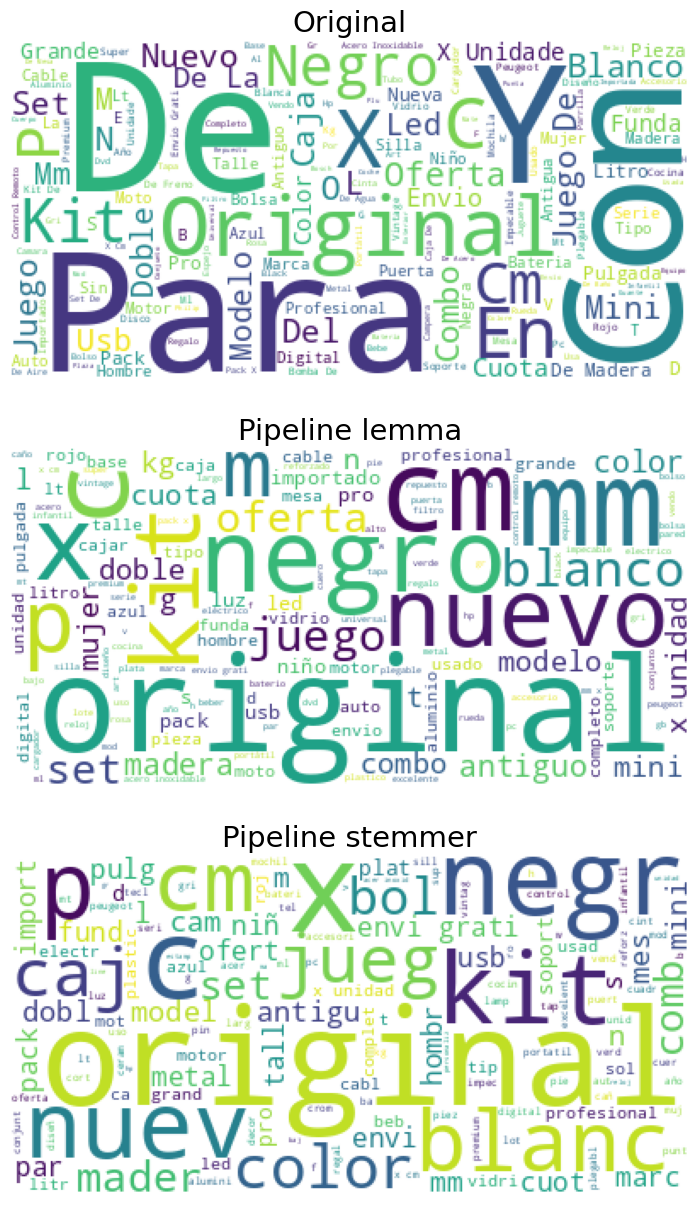

In [24]:
plt.figure(figsize=(20,15))
for i, wc_obj, title in zip(range(3),
                     [wc_init, wc_lemma, wc_stemmer],
                     ["Original", "Pipeline lemma", "Pipeline stemmer"]):
    plt.subplot(3,1,i+1)
    plt.title(title, fontsize=21)
    plt.imshow(wc_obj)
    plt.axis("off")

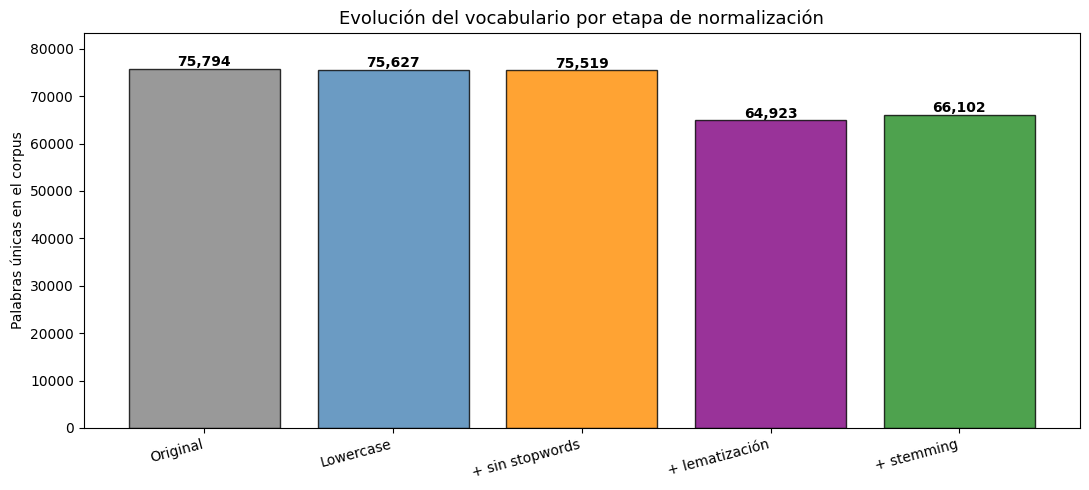


Reducción acumulada respecto al corpus original:
Etapa                            |V|    Δ acum.
--------------------------------------------------
Original                      75,794      0.00%
Lowercase                     75,627      0.22%
+ sin stopwords               75,519      0.36%
+ lematización                64,923     14.34%
+ stemming                    66,102     12.79%


In [26]:
# =================================================================================
# Ítem Extra: Visualización del impacto acumulado de cada etapa
# =================================================================================

# Calcular el vocabulario acumulado etapa por etapa
v_init   = len(np.unique(" ".join(data["title"]).split()))
v_lower  = len(np.unique(" ".join(data_lower).split()))
v_no_sw  = len(np.unique(" ".join(data_sw).split()))
v_lemma  = len(np.unique(" ".join(data_lemma["title"]).split()))
v_stem   = len(np.unique(" ".join(data_stemmer["title"]).split()))

etapas = ["Original", "Lowercase", "+ sin stopwords", "+ lematización", "+ stemming"]
valores = [v_init, v_lower, v_no_sw, v_lemma, v_stem]
colores = ["gray", "steelblue", "darkorange", "purple", "forestgreen"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(etapas, valores, color=colores, edgecolor="black", alpha=0.8)

for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{v:,}", ha="center", fontsize=10, fontweight="bold")

ax.set_title("Evolución del vocabulario por etapa de normalización",
             fontsize=13)
ax.set_ylabel("Palabras únicas en el corpus")
ax.set_ylim(0, max(valores) * 1.10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# Tabla acumulada
print("\nReducción acumulada respecto al corpus original:")
print(f"{'Etapa':<25} {'|V|':>10} {'Δ acum.':>10}")
print("-" * 50)
for etapa, v in zip(etapas, valores):
    delta = (1 - v / v_init) * 100
    print(f"{etapa:<25} {v:>10,} {delta:>9.2f}%")

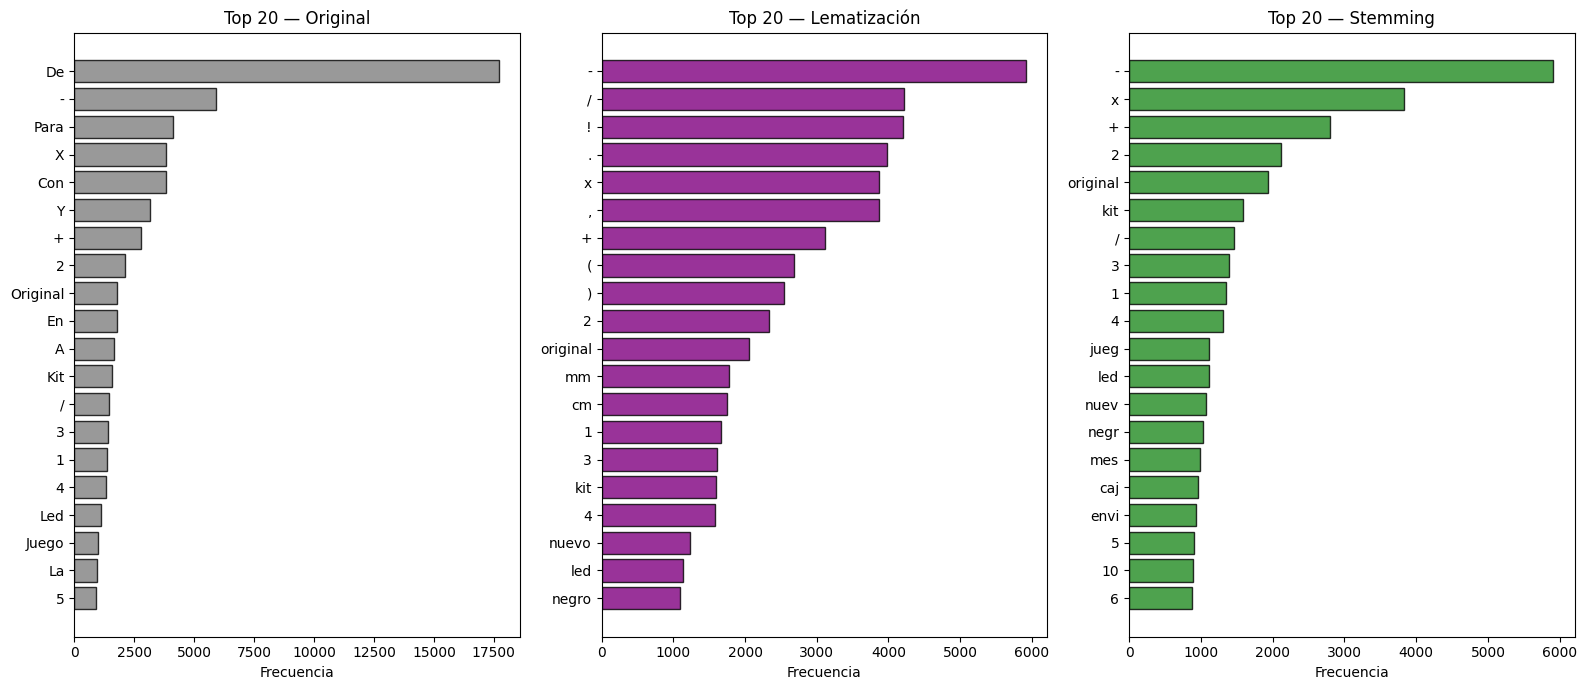

In [29]:
# =================================================================================
# Ítem Extra: Top 20 tokens más frecuentes por corpus
# =================================================================================

from collections import Counter

def top_tokens(df: pd.DataFrame, n: int = 20) -> list:
    """
    Retorna los n tokens más frecuentes del corpus.

    Parámetros
    ----------
    df : pd.DataFrame -- DataFrame con columna 'title'.
    n  : int          -- Cantidad de tokens a retornar (default: 20).

    Retorna
    -------
    list[tuple] -- Lista de (token, frecuencia) ordenada descendente.
    """
    corpus = " ".join(df["title"])
    return Counter(corpus.split()).most_common(n)


top_orig = top_tokens(data)
top_lemma = top_tokens(data_lemma)
top_stem = top_tokens(data_stemmer)

# Visualización en 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
datos = [(top_orig, "Original", "gray"),
         (top_lemma, "Lematización", "purple"),
         (top_stem, "Stemming", "forestgreen")]

for ax, (tops, nombre, color) in zip(axes, datos):
    palabras = [t[0] for t in tops][::-1]
    frecs = [t[1] for t in tops][::-1]
    ax.barh(palabras, frecs, color=color, alpha=0.8, edgecolor="black")
    ax.set_title(f"Top 20 — {nombre}", fontsize=12)
    ax.set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

### **Pregunta 3:**

##### **Genera una conclusión de lo que logras observar en los word cloud. ¿Hubo variación en la frencuencia de los *tokens*?**

La comparación entre las nubes de palabras original, lematizada y stemmatizada evidencia que el preprocesamiento transforma significativamente la calidad informativa del corpus. En la versión original predominan términos funcionales y signos de puntuación que aportan poco valor discriminativo para clasificación, mientras que tras el procesamiento emergen palabras con contenido semántico relevante, como atributos físicos, estados del producto y especificaciones técnicas, que son más útiles para que el modelo identifique patrones entre categorías.

También se observan diferencias entre lematización y stemming. La lematización conserva mejor la legibilidad y mantiene formas lingüísticas más interpretables, lo que la hace adecuada para análisis exploratorio; en cambio, el stemming logra una mayor compresión del vocabulario, lo que puede beneficiar modelos clásicos de clasificación como bag-of-words o TF-IDF, aunque a costa de perder claridad semántica.

Sin embargo, el preprocesamiento aplicado aún no resuelve completamente ciertos problemas, como la presencia de signos de puntuación, números o códigos alfanuméricos que pueden introducir ruido. Esto sugiere que el pipeline puede fortalecerse con etapas adicionales de limpieza. En conjunto, el preprocesamiento mejora sustancialmente la representación textual, pero el desempeño final dependerá también del modelo utilizado y de la técnica de representación elegida.

#### **Ejercicio 9:**

Nota que generamos 3 corpus (*corpus_init*, *corpus_lemma*, *corpus_stemmer*). A partir de estos tres corpus, concluye como cambió la dimensionalidad de cada corpus y el por qué cambió.

In [ ]:
### TU CÓDIGO ASÍ ###
corpus_init_word_count = len(np.unique(corpus_init.split()))
corpus_lemma_word_count = len(np.unique(corpus_lemma.split()))
corpus_stemmer_word_count = len(np.unique(corpus_stemmer.split()))

print(f"Vocabulario Original: {corpus_init_word_count}")
print(f"Vocabulario Lema: {corpus_lemma_word_count}")
print(f"Vocabulario Stemmer: {corpus_stemmer_word_count}")

print(f"Reducción con Lematización: {corpus_init_word_count - corpus_lemma_word_count}")
print(f"Reducción con Stemming: {corpus_init_word_count - corpus_stemmer_word_count}")
#####################

Vocabulario Original: 75794
Vocabulario Lema: 64923
Vocabulario Stemmer: 66102
Reducción con Lematización: 10871
Reducción con Stemming: 9692


### **Pregunta 4:**

##### ¿Cómo podrías emplear lo visto en tu ámbito profesional? ¿Consideras útil implementar solo esta parte, o crees que se debería complementar con otras técnicas de NLP?

**APONTE ZURITA WILLIAM ROMARIO**

**1. Aplicación en el ámbito profesional:**
En el sector bancario (mi enfoque profesional), estas técnicas son fundamentales para el procesamiento y clasificación automática de glosas de transferencias, la detección de fraudes mediante el análisis de patrones en los conceptos de pago, y la organización de reclamos o sugerencias de clientes. Al normalizar el texto, podemos identificar la intención del usuario de manera más robusta, independientemente de variaciones gramaticales o errores de escritura menores.

**2. Utilidad y complemento con otras técnicas:**
Considero que implementar solo el pre-procesamiento es un primer paso crítico para asegurar la calidad de los datos, pero es insuficiente por sí solo. Para obtener valor real, debe complementarse con técnicas de representación vectorial (como Word2Vec, FastText o BERT) y modelos de aprendizaje supervisado o no supervisado. El pre-procesamiento actúa como el filtro necesario para reducir el ruido, permitiendo que los algoritmos posteriores se enfoquen en la semántica y el contexto relevante de la información financiera.

**VITERI AYALA FLAVIA KAMILA**

En mi rol en CAF trabajo con un volumen importante de documentos institucionales:
informes de evaluación, contratos, propuestas, marcos lógicos, lecciones
aprendidas y reportes de cierre de proyectos. Las técnicas de
normalización vistas en esta práctica son directamente aplicables a
varios casos de uso:

**1. Clasificación automática de proyectos por sector y subsector**

**Problema**: clasificar proyectos en una taxonomía de cinco niveles
(Agenda → Sector → Subsector → Línea → Sublínea) a partir del título y
la descripción del proyecto. Hoy esta clasificación se hace
manualmente.

**Aplicación**:
- Pipeline: lowercase → sin stopwords (lista personalizada que preserve
  `sin`, `no`, `contra`) → lematización con spaCy `es_core_news_md`
  (más preciso que el `_sm`).
- Sobre el texto normalizado se entrena un clasificador (TF-IDF + SVM
  como baseline, o un modelo de embeddings para mejor desempeño).

**2. Agrupación temática de lecciones aprendidas**

**Problema**: encontrar lecciones aprendidas similares entre proyectos
distintos para construir una base de conocimiento institucional.

**Aplicación**:
- Pipeline de normalización + vectorización con embeddings
  multilingües (modelos de Azure OpenAI ya integrados en mi pipeline
  `caf_eval_ex_post_ai`).
- Clustering con HDBSCAN para descubrir temas recurrentes.
- La lematización ayuda a que `riesgo cambiario`, `riesgos cambiarios`
  y `riesgo de tipo de cambio` se agrupen como variantes del mismo
  concepto.
